# Credit Card Defaults

#### Proyect Overview

Credit default prediction is one of the most important applications of machine learning in retail banking. Accurately identifying customers who are likely to default on their next payment enables financial institutions to reduce credit risk, optimize lending decisions, and improve portfolio profitability.

This project develops a binary classification model to predict whether a credit card customer will default on their next monthly payment using demographic information, credit limits, billing statements, payment history, and engineered financial indicators.

Beyond building an accurate predictive model, the project explores how different feature engineering strategies and machine learning algorithms affect classification performance. Several feature representations are evaluated to determine whether aggregated financial variables can improve prediction or reduce model complexity without sacrificing performance.

- **Feature engineering:** Do business-oriented features improve predictive performance?
- **Feature aggregation:**  Can monthly billing and payment histories be summarized without losing important information?
- **Model comparison:** Logistic Regression and Random Forest are evaluated under the same experimental framework.
- **Model optimization:** Cross-validation, hyperparameter tuning, and threshold optimization are used to maximize the F1-score while preventing overfitting.

---

#### Dataset

https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

The dataset contains **30,000 credit card clients** described by **23 predictor variables** and one binary target variable indicating whether the customer defaulted on the next monthly payment.

| Class | Label | Count | Proportion |
|-------|-------|-------|------------|
| Non-Default | 0 | 23364 | 77.88% |
| Default | 1 | 6636 | 22.12% |

The dataset presents a moderate class imbalance, which is considered throughout model training and evaluation.

---

#### Evaluation Metric

The **F1-score** is used as the primary evaluation metric. In credit risk prediction, both types of classification errors carry financial consequences:

- A **false negative** (predicting that a customer will not default when they actually do) may lead to financial losses and increased credit risk.
- A **false positive** (predicting default for a customer who would repay) may result in rejecting reliable customers or offering unnecessarily restrictive credit conditions.

The F1-score provides a balanced evaluation by jointly considering Precision and Recall, making it more informative than Accuracy for an imbalanced classification problem.

---

#### Project Workflow

1. Dataset & Bussinnes Understanding
2. SQL Data Exploration
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Preprocessing
6. Logistic Regression
7. Random Forest
8. Cross-Validation
9. Hyperparameter Optimization (GridSearchCV)
10. Decision Threshold optimization
11. Final Model Evaluation on an Unseen Test Set
12. Conclusions

### 1. Dataset & Bussinnes Understanding

In [1]:
!pip install xlrd

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [3]:
df = pd.read_csv("credit_default.csv", skiprows=1)
df = df.rename(columns={"default payment next month":"Default_payment"})
df = df.drop("ID", axis=1)

## Auxiliary functions

In [4]:
def train_val_test_split(df, rstate=137, shuffle=True, stratify = None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(test_set, test_size= 0.5, random_state=rstate, shuffle=shuffle, stratify =strat)
    return (train_set, val_set, test_set)

In [5]:
def feat_div(df, feature_name):
    X = df.drop(feature_name, axis = 1)
    y = df[feature_name].copy()
    return(X, y)

In [6]:
df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,80000,1,3,1,41,1,-1,0,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [7]:
df["MARRIAGE"].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   LIMIT_BAL        30000 non-null  int64
 1   SEX              30000 non-null  int64
 2   EDUCATION        30000 non-null  int64
 3   MARRIAGE         30000 non-null  int64
 4   AGE              30000 non-null  int64
 5   PAY_0            30000 non-null  int64
 6   PAY_2            30000 non-null  int64
 7   PAY_3            30000 non-null  int64
 8   PAY_4            30000 non-null  int64
 9   PAY_5            30000 non-null  int64
 10  PAY_6            30000 non-null  int64
 11  BILL_AMT1        30000 non-null  int64
 12  BILL_AMT2        30000 non-null  int64
 13  BILL_AMT3        30000 non-null  int64
 14  BILL_AMT4        30000 non-null  int64
 15  BILL_AMT5        30000 non-null  int64
 16  BILL_AMT6        30000 non-null  int64
 17  PAY_AMT1         30000 non-null  int64
 18  PAY_AM

### 2. SQL Exploration

In [9]:
conn = sqlite3.connect("credit_default.db")
df.to_sql("credit_clients", conn, if_exists="replace", index=False)
cursor = conn.cursor()

### 2.1 Class distribution

In [10]:
query_count = """
SELECT 
    Default_payment,
    COUNT(*) AS Cases,
    COUNT(*) * 100.0 / (
        SELECT COUNT(*) 
        FROM credit_clients
    ) AS Percentage
FROM credit_clients
GROUP BY Default_payment
"""
pd.read_sql_query(query_count, conn)

,Default_payment,Cases,Percentage
0,0,23364,77.88
1,1,6636,22.12


### 2.2 Education

In [11]:
query_count = """
SELECT COUNT(*)
        FROM credit_clients
        GROUP BY Education
"""
pd.read_sql_query(query_count, conn)

,COUNT(*)
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


In [12]:
query_education = """
SELECT 
    Education,
    Default_payment,
    COUNT(*) AS Cases,
    ROUND(COUNT(*) * 100.0 / (
        SELECT COUNT(*)
        FROM credit_clients c2
        WHERE c2.Education = c1.Education
    ),2) AS Percentage
FROM credit_clients c1
GROUP BY Education, Default_payment
"""
pd.read_sql_query(query_education, conn)


,EDUCATION,Default_payment,Cases,Percentage
0,0,0,14,100.00
1,1,0,8549,80.77
2,1,1,2036,19.23
3,2,0,10700,76.27
4,2,1,3330,23.73
5,3,0,3680,74.84
6,3,1,1237,25.16
7,4,0,116,94.31
8,4,1,7,5.69
9,5,0,262,93.57


### 2.3 Marriage

In [13]:
query_marriage = """
SELECT 
    Marriage,
    Default_payment,
    COUNT(*) AS Cases,
    ROUND(COUNT(*) * 100.0 / (
        SELECT COUNT(*)
        FROM credit_clients c2
        WHERE c2.Marriage = c1.Marriage
    ),2) AS Percentage
FROM credit_clients c1
GROUP BY Marriage, Default_payment
"""

pd.read_sql_query(query_marriage, conn)

,MARRIAGE,Default_payment,Cases,Percentage
0,0,0,49,90.74
1,0,1,5,9.26
2,1,0,10453,76.53
3,1,1,3206,23.47
4,2,0,12623,79.07
5,2,1,3341,20.93
6,3,0,239,73.99
7,3,1,84,26.01


### 2.4 Credit limit

In [14]:
query = """
SELECT AVG(LIMIT_BAL)
FROM credit_clients
GROUP BY Default_payment
"""
pd.read_sql_query(query, conn)

,AVG(LIMIT_BAL)
0,178099.726074
1,130109.656420


**We are looking at the difference between average balance limits**

This suggest considerable lower limits to the costumers more likely to default payments, as suspected.

In [15]:
query = """
WITH limit_range AS(
    SELECT
        CASE
            WHEN LIMIT_BAL BETWEEN 10000 AND 257500 THEN 'Low'
            WHEN LIMIT_BAL BETWEEN 257501 AND 550000 THEN 'Mid'
            ELSE 'High'
        END AS limit_group,
        Default_payment
    FROM credit_clients
)

SELECT limit_group AS limits,
    Default_payment, 
    COUNT(*) AS client_num
FROM limit_range
GROUP BY limit_group, Default_payment
ORDER BY client_num DESC;
"""

pd.read_sql_query(query, conn)

,limits,Default_payment,client_num
0,Low,0,17584
1,Low,1,5699
2,Mid,0,5662
3,Mid,1,925
4,High,0,118
5,High,1,12


In [16]:
query_BILL = """
WITH billing AS (
    SELECT
        CASE 
            WHEN BILL_AMT4 BETWEEN 0 AND 100000 THEN 'LOW'
            ELSE 'HIGH'
        END AS Bill_group,
        BILL_AMT4,
        Default_payment
    FROM credit_clients
)

SELECT Bill_group AS range,
    Default_payment,
    COUNT(*) AS client_num
FROM Billing
GROUP BY Bill_group, Default_payment
"""

pd.read_sql_query(query_BILL, conn)

,range,Default_payment,client_num
0,HIGH,0,3734
1,HIGH,1,907
2,LOW,0,19630
3,LOW,1,5729


### 2.5 Age

In [17]:
query_age = """
WITH age_groups AS (
    SELECT 
        CASE
            WHEN Age BETWEEN 21 AND 30 THEN '(21-30) Young Adult'
            WHEN Age BETWEEN 31 AND 40 THEN '(31-40) Adults'
            WHEN Age BETWEEN 41 AND 50 THEN '(41-50) Middle-aged Adults'
            WHEN Age BETWEEN 51 AND 60 THEN '(51-60) Older Adults'
            ELSE '(61+) Seniors'
        END AS Age_div,
        Default_payment
    FROM credit_clients
)

SELECT
    Age_div,
    Default_payment,
    COUNT(*) AS Cases,
    ROUND(
        COUNT(*) * 100.0 /(
        SELECT COUNT(*)
        FROM age_groups ag2
        WHERE ag2.Age_div = ag1.Age_div
    ), 2) AS Percentage
    FROM age_groups ag1
    GROUP BY Age_div, Default_payment
    ORDER BY Age_div, Default_payment
"""

pd.read_sql_query(query_age, conn)

,Age_div,Default_payment,Cases,Percentage
0,(21-30) Young Adult,0,8542,77.56
1,(21-30) Young Adult,1,2471,22.44
2,(31-40) Adults,0,8524,79.57
3,(31-40) Adults,1,2189,20.43
4,(41-50) Middle-aged Adults,0,4606,76.70
5,(41-50) Middle-aged Adults,1,1399,23.30
6,(51-60) Older Adults,0,1493,74.76
7,(51-60) Older Adults,1,504,25.24
8,(61+) Seniors,0,199,73.16
9,(61+) Seniors,1,73,26.84


### 2.6 Payment Delay

In [18]:
query_delay = """
SELECT (
            AVG(Pay_0) +
            AVG(Pay_2) +
            AVG(Pay_3) +
            AVG(Pay_4) +
            AVG(Pay_5) +
            AVG(Pay_6)
        )/6 AS Average_delay,
    Default_payment
FROM credit_clients
GROUP BY Default_payment
"""

pd.read_sql_query(query_delay, conn)

,Average_delay,Default_payment
0,-0.330023,0
1,0.337176,1


### 2.7 Average Bill

In [19]:
query_avg_bill = """
SELECT ROUND((
            AVG(Bill_amt1) +
            AVG(Bill_amt2) +
            AVG(Bill_amt3) +
            AVG(Bill_amt4) +
            AVG(Bill_amt5) +
            AVG(Bill_amt6) 
        )/6, 2) AS Average_bill,
    Default_payment
FROM credit_clients
GROUP BY Default_payment
"""

pd.read_sql_query(query_avg_bill, conn)

,Average_bill,Default_payment
0,45404.82,0
1,43470.49,1


### 3. Exploratory Data Analysis (EDA)

<Axes: xlabel='Default_payment', ylabel='count'>

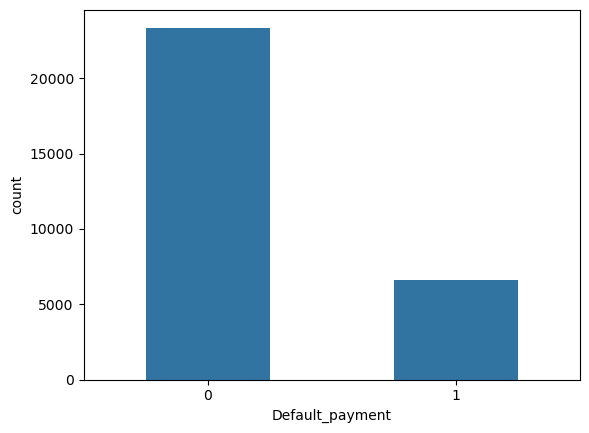

In [20]:
import seaborn as sns
sns.countplot(data = df, x="Default_payment", width=0.5)

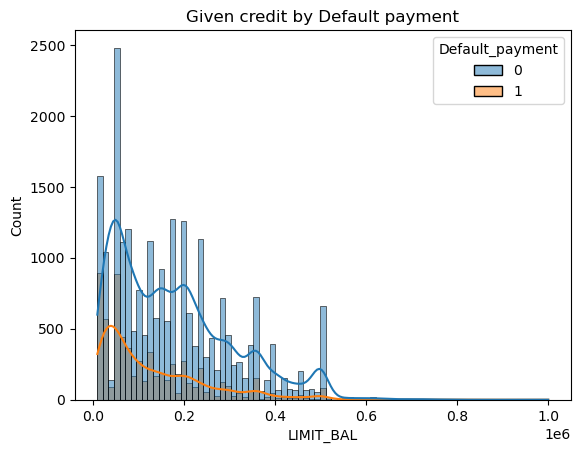

In [21]:
sns.histplot(data=df, x="LIMIT_BAL", hue="Default_payment", kde=True)
plt.title("Given credit by Default payment")
plt.show()

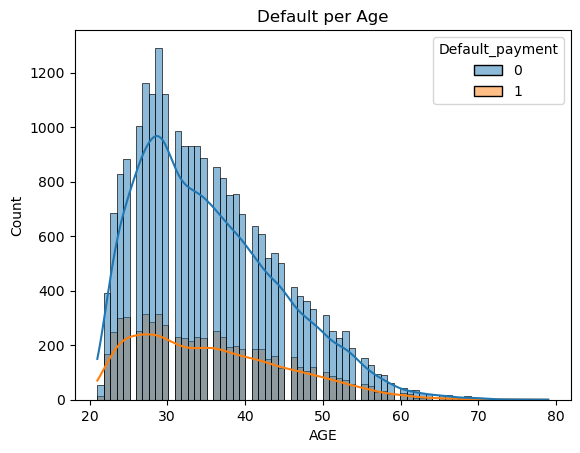

In [22]:
sns.histplot(data=df, x= "AGE", hue="Default_payment", kde=True)
plt.title("Default per Age")
plt.show()

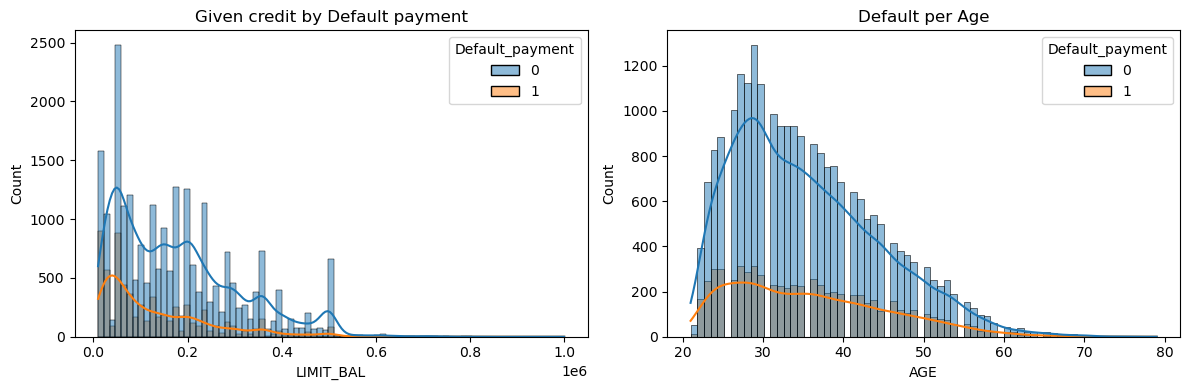

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data = df,
    x = "LIMIT_BAL",
    hue = "Default_payment",
    kde = True,
    ax = axes[0]
)
axes[0].set_title("Given credit by Default payment")

sns.histplot(
    data=df,
    x="AGE",
    hue="Default_payment",
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Default per Age")

plt.tight_layout()
plt.show()

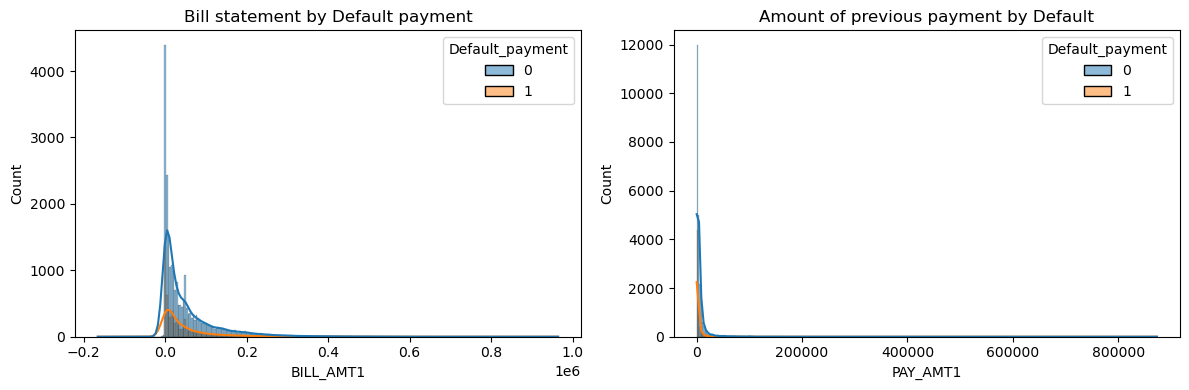

In [24]:
fig, axes = plt.subplots(1, 2, figsize= (12, 4))

sns.histplot(
    data=df,
    x = "BILL_AMT1",
    hue = "Default_payment",
    kde=True,
    ax = axes[0]
)
axes[0].set_title("Bill statement by Default payment")

sns.histplot(
    data=df,
    x="PAY_AMT1",
    hue="Default_payment",
    kde=True,
    ax= axes[1]
)
axes[1].set_title("Amount of previous payment by Default")

#axes[0].set_xlim(0, 200000)
#axes[1].set_xlim(0, 100000)
plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import mannwhitneyu

default = df[df["Default_payment"] == 1]

non_default = df[df["Default_payment"] == 0]

stat, p = mannwhitneyu(
    default["LIMIT_BAL"],
    non_default["LIMIT_BAL"]
)

print(p)

1.2255485818223303e-189


The EDA showed that the majority of the numerical variables exhibit a considerable positive skew, resulting in asymmetric distributions with long right tails due to high-value outliers in the monetary variables. It is important to note that these outliers, found in variables such as credit limit and payment amounts, represent real customers with unusual financial activity rather than data errors. Therefore, they were retained, as removing them could eliminate valuable information and potentially reduce the predictive performance of the models.

In [26]:
corr = df.corr(numeric_only = True)

<Axes: >

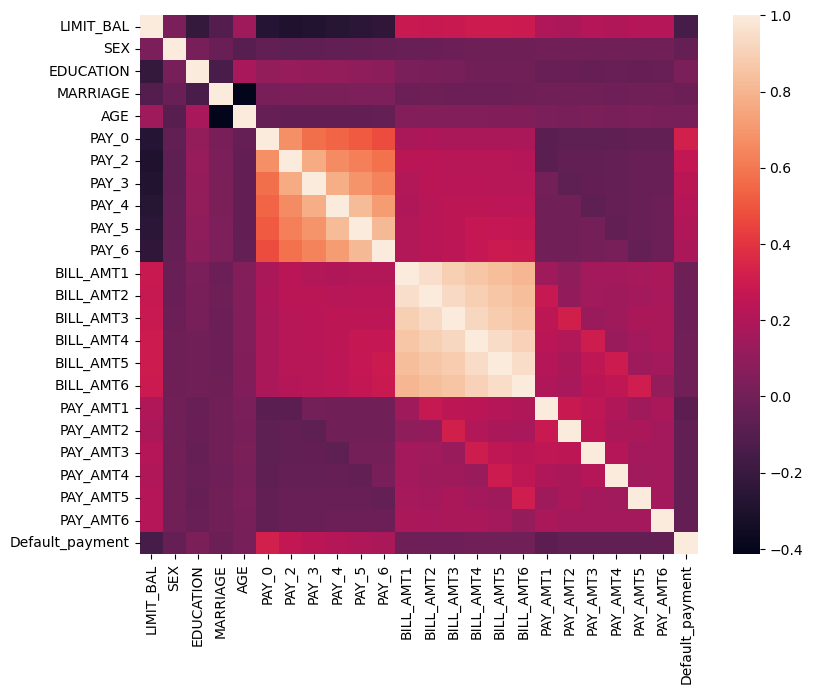

In [27]:
plt.figure(figsize = (9,7))
sns.heatmap(corr)

### Key Findings
1. The dataset is moderately imbalanced (≈22% default cases).
2. Customers with lower credit limits tend to exhibit higher default rates.
3. Payment history variables (PAY_*) show the strongest relationship with the target.
4. Consecutive monthly bill amounts (BILL_AMT*) are highly correlated.

### 4. Feature Engineering

In [28]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df_bsn = df.copy()

df_bsn["Delinq_month_count"] = (
    (df[pay_cols] > 0).sum(axis=1)
)

AVG_BILL = df_bsn[bill_cols].mean(axis=1)

df_bsn["Utilization_ratio"] = (
    AVG_BILL / df["LIMIT_BAL"]
)
df.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_payment
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [29]:
df_mod = df.copy()
df_mod["AVG_payment"] = df_mod[pay_amt_cols].mean(axis=1)
df_mod["AVG_BILL"] = df_mod[bill_cols].mean(axis=1)
df_mod.head(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_payment,AVG_payment,AVG_BILL
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,689,0,0,0,0,1,114.833333,1284.000000
1,120000,2,2,2,26,-1,2,0,0,0,...,3261,0,1000,1000,1000,0,2000,1,833.333333,2846.166667
2,90000,2,2,2,34,0,0,0,0,0,...,15549,1518,1500,1000,1000,1000,5000,0,1836.333333,16942.166667
3,50000,2,2,1,37,0,0,0,0,0,...,29547,2000,2019,1200,1100,1069,1000,0,1398.000000,38555.666667
4,50000,1,2,1,57,-1,0,-1,0,0,...,19131,2000,36681,10000,9000,689,679,0,9841.500000,18223.166667


In [30]:
df_rmv = df_mod.copy()
cols_rmv = pay_amt_cols + bill_cols
df_rmv = df_rmv.drop(cols_rmv, axis=1)
df_rmv

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,Default_payment,AVG_payment,AVG_BILL
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,1,114.833333,1284.000000
1,120000,2,2,2,26,-1,2,0,0,0,2,1,833.333333,2846.166667
2,90000,2,2,2,34,0,0,0,0,0,0,0,1836.333333,16942.166667
3,50000,2,2,1,37,0,0,0,0,0,0,0,1398.000000,38555.666667
4,50000,1,2,1,57,-1,0,-1,0,0,0,0,9841.500000,18223.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,0,0,7091.666667,120891.500000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,0,0,2415.000000,3530.333333
29997,30000,1,2,2,37,4,3,2,-1,0,0,1,5216.666667,11749.333333
29998,80000,1,3,1,41,1,-1,0,0,0,-1,1,24530.166667,44435.166667


### 5. Data Preprocessing

In [31]:
train, val, test = train_val_test_split(df, stratify="Default_payment")

X_train_base, y_train_base = feat_div(train, 'Default_payment')
X_val_base, y_val_base = feat_div(val, 'Default_payment')
X_test_base, y_test_base = feat_div(test, 'Default_payment')

train_set, val_set, test_set = train_val_test_split(df_bsn, stratify="Default_payment")

X_train, y_train = feat_div(train_set, 'Default_payment')
X_val, y_val = feat_div(val_set, 'Default_payment')
X_test, y_test = feat_div(test_set, 'Default_payment')

train_mod_set, val_mod_set, test_mod_set = train_val_test_split(df_mod, stratify="Default_payment")

X_train_m, y_train_m = feat_div(train_mod_set, 'Default_payment')
X_val_m, y_val_m = feat_div(val_mod_set, 'Default_payment')
X_test_m, y_test_m = feat_div(test_mod_set, 'Default_payment')

train_r_set, val_r_set, test_r_set = train_val_test_split(df_rmv, stratify="Default_payment")

X_train_r, y_train_r = feat_div(train_r_set, 'Default_payment')
X_val_r, y_val_r = feat_div(val_r_set, 'Default_payment')
X_test_r, y_test_r = feat_div(test_r_set, 'Default_payment')

Hypothesis: Three feature sets were created to evaluate if different feature engineering strategies improve the predictive performance of the models.

• Baseline: The baseline dataset is the downloaded raw data. 

• Dataset 1: The original dataset enriched with two engineered features: Utilization ratio and Delinquent Month Count.

• Dataset 2: This one will be dataset 1 with the additional feature Average Payment Amount (AVG_payment) and the Average Bill.

• Dataset 3: This last will be dataset 2, but, we removed Bill_AMT1-Bill_AMT6 and Pay_0-Pay_6 features to evaluate whether a more compact representation of these features improves the predictive performance.

### 6. Baseline Models

### 6.1 Baseline Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve 

base_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

base_lr.fit(X_train_base, y_train_base)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [33]:
y_pred = base_lr.predict(X_val_base)

print("The Baseline F1 score for Logestic regression is:", f1_score(y_val_base, y_pred))
print(classification_report(y_val_base, y_pred))
print(confusion_matrix(y_val_base, y_pred))

The Baseline F1 score for Logestic regression is: 0.4759776536312849
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3272 1401]
 [ 475  852]]


### 6.2 Baseline Random Forest 

In [34]:
from sklearn.ensemble import RandomForestClassifier

base_rf = RandomForestClassifier(n_estimators=60, random_state = 137, n_jobs=-1, class_weight = "balanced")
base_rf.fit(X_train_base, y_train_base)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = base_rf.predict(X_val_base)

print("The Baseline F1 score for Random Forest is:", f1_score(y_val_base, y_pred))
print(classification_report(y_val_base, y_pred))
print(confusion_matrix(y_val_base, y_pred))

The Baseline F1 score for Random Forest is: 0.44133799301048426
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.65      0.33      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

[[4439  234]
 [ 885  442]]


With this baseline test we observe an slight better performance for the Logistic Regression model over Random forest one, considering only the F1_score for Default cases. However, it is important to notice the weighted average between models and the supirior capacity from Random Forest to correctly predict customers that won't Default.

### 7. logistic regression model

### 7.1 Dataset 1 prediction

In [36]:
lr_default_std = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_rbt = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_std.fit(X_train, y_train)
lr_default_rbt.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


In [37]:
y_pred_std = lr_default_std.predict(X_val)
y_pred_rbt = lr_default_rbt.predict(X_val)

In [38]:
print("Standard Scaler:")
print(classification_report(y_val, y_pred_std))
print(confusion_matrix(y_val, y_pred_std))

print("Robust Scaler:")
print(classification_report(y_val, y_pred_rbt))
print(confusion_matrix(y_val, y_pred_rbt))

Standard Scaler:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

[[3799  874]
 [ 558  769]]
Robust Scaler:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

[[3798  875]
 [ 558  769]]


### 7.2 Dataset 2 prediction

In [39]:
lr_default_std_m = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_rbt_m = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_std_m.fit(X_train_m, y_train_m)
lr_default_rbt_m.fit(X_train_m, y_train_m)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


In [40]:
y_pred_std_m = lr_default_std_m.predict(X_val_m)
y_pred_rbt_m = lr_default_rbt_m.predict(X_val_m)

In [41]:
print("Standard Scaler:")
print(classification_report(y_val_m, y_pred_std_m))
print(confusion_matrix(y_val_m, y_pred_std_m))

print("Robust Scaler:")
print(classification_report(y_val_m, y_pred_rbt_m))
print(confusion_matrix(y_val_m, y_pred_rbt_m))

Standard Scaler:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3272 1401]
 [ 475  852]]
Robust Scaler:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3272 1401]
 [ 477  850]]


### 7.3 Dataset 3 prediction

In [42]:
lr_default_std_r = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_rbt_r = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_std_r.fit(X_train_r, y_train_r)
lr_default_rbt_r.fit(X_train_r, y_train_r)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False
,penalty,'l2'
,dual,False


In [43]:
y_pred_std_r = lr_default_std_r.predict(X_val_r)
y_pred_rbt_r = lr_default_rbt_r.predict(X_val_r)

In [44]:
print("Standard Scaler:")
print(classification_report(y_val_r, y_pred_std_r))
print(confusion_matrix(y_val_r, y_pred_std_r))

print("Robust Scaler:")
print(classification_report(y_val_r, y_pred_rbt_r))
print(confusion_matrix(y_val_r, y_pred_rbt_r))

Standard Scaler:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3281 1392]
 [ 480  847]]
Robust Scaler:
              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000

[[3280 1393]
 [ 479  848]]


The introduction of aggregated billing and payment features produced the same result as the baseline test. The results suggest that these aggregated variables introduces redundancy rather than complementary information. Dataset 1 exihibits higher metrics, this indicates that there is valuable information inside the two variables regarding the delinquent month count and utilization ratio.

### 8. Random Forest Model

### 8.1 Dataset 1 RF predicition

In [45]:
clf_rnd = RandomForestClassifier(n_estimators=60, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd.fit(X_train, y_train)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
y_pred = clf_rnd.predict(X_val)

In [47]:
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print("F1 score of original Dataset:", f1_score(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

[[4451  222]
 [ 873  454]]
F1 score of original Dataset: 0.45332001997004495


### 8.2 Dataset 2 RF prediction

In [48]:
clf_rnd_m = RandomForestClassifier(n_estimators=50, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd_m.fit(X_train_m, y_train_m)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
y_pred_m = clf_rnd_m.predict(X_val_m)

In [50]:
print(classification_report(y_val_m, y_pred_m))
print(confusion_matrix(y_val_m, y_pred_m))
print("F1 score dataset 2:", f1_score(y_val_m, y_pred_m))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000

[[4454  219]
 [ 874  453]]
F1 score dataset 2: 0.4532266133066533


### 8.3 Dataset 3 RF prediction

In [51]:
clf_rnd_r = RandomForestClassifier(n_estimators=50, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rnd_r.fit(X_train_r, y_train_r)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred_r = clf_rnd_r.predict(X_val_r)

In [53]:
print(classification_report(y_val_r, y_pred_r))
print(confusion_matrix(y_val_r, y_pred_r))
print("F1 score dataset 3:", f1_score(y_val_r, y_pred_r))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

[[4420  253]
 [ 865  462]]
F1 score dataset 3: 0.4524975514201763


On the other hand, Random forest exhibits a presistent behaviour over the aggragated features, the F1_score for default cases improves in 0.01. With these results, we concluded that the best Dataset to work with is Dataset 1. First, it slightly empowered Logistic Regression model F1_score and secondly there is no difference for Random forest model.

### 9. Features Importance

In [98]:
clf_rnd_.feature_importances_

NameError: name 'clf_rnd_fi' is not defined

In [55]:
# We extract the top 10 important features in order to achive a higher classification quality
feature_importances = {
    name: score
    for name, score in zip(X_train.columns, clf_rnd.feature_importances_)
}

In [56]:
features_impo_sorted = pd.Series(feature_importances).sort_values(ascending=False)
features_impo_sorted.head(13)

PAY_0                 0.078600
Delinq_month_count    0.064639
Utilization_ratio     0.064368
AGE                   0.058515
BILL_AMT1             0.054773
LIMIT_BAL             0.053815
BILL_AMT2             0.048898
PAY_AMT2              0.048571
BILL_AMT3             0.045575
PAY_AMT1              0.045484
BILL_AMT5             0.044618
PAY_AMT3              0.044615
BILL_AMT4             0.044071
dtype: float64

In [57]:
columns = list(features_impo_sorted.head(13).index)
columns

['PAY_0',
 'Delinq_month_count',
 'Utilization_ratio',
 'AGE',
 'BILL_AMT1',
 'LIMIT_BAL',
 'BILL_AMT2',
 'PAY_AMT2',
 'BILL_AMT3',
 'PAY_AMT1',
 'BILL_AMT5',
 'PAY_AMT3',
 'BILL_AMT4']

In [58]:
'Default_payment' in X_train.columns

False

In [59]:
X_train_reduced = X_train[columns].copy()
X_val_reduced = X_val[columns].copy()

### 9.1 Logistic Regression Important Feature

In [60]:
lr_default_if = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight = "balanced", max_iter=2000))
])

lr_default_if.fit(X_train_reduced, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [61]:
y_pred_rd_lr = lr_default_if.predict(X_val_reduced)

In [62]:
print(classification_report(y_val, y_pred_rd_lr))
print(confusion_matrix(y_val, y_pred_rd_lr))
print("F1 score Logistic regression, importat features:", f1_score(y_val, y_pred_rd_lr))

              precision    recall  f1-score   support

           0       0.87      0.81      0.84      4673
           1       0.47      0.58      0.52      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000

[[3798  875]
 [ 560  767]]
F1 score Logistic regression, importat features: 0.5166722802290333


### 9.2 Random Forest Important Feature

In [63]:
clf_rf_if = RandomForestClassifier(n_estimators= 60, random_state = 137, n_jobs=-1, class_weight = "balanced")
clf_rf_if.fit(X_train_reduced, y_train)

,n_estimators,60
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_pred_rd = clf_rf_if.predict(X_val_reduced)

In [65]:
print(classification_report(y_val, y_pred_rd))
print(confusion_matrix(y_val, y_pred_rd))
print("F1 score Random Forest, importat features:", f1_score(y_val, y_pred_rd))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.65      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

[[4426  247]
 [ 865  462]]
F1 score Random Forest, importat features: 0.4538310412573674


The results on this section have shown that keeping the features with more important is not the ideal thing to do, due to some information inside those features

### 10. cross val

In [66]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

### 10.1 Cross Validation Dataset 1

In [67]:
cv = StratifiedKFold(
    n_splits = 5, shuffle=True, random_state=137
)

lr_score = cross_val_score(
    lr_default_std, X_train, y_train, cv=cv, scoring="f1"
)

rf_score = cross_val_score(
    clf_rnd, X_train, y_train, cv=cv, scoring="f1"
)

In [68]:
print("Logistic Regression:")
print("F1 scores:", lr_score)
print("Mean:", lr_score.mean())
print("Std:", lr_score.std())

Logistic Regression:
F1 scores: [0.53310696 0.51212634 0.5216895  0.53104213 0.51984349]
Mean: 0.5235616829580766
Std: 0.007683313472829779


In [69]:
print("Random Forest")
print("F1 scores:", rf_score)
print("Mean:", rf_score.mean())
print("Std:", rf_score.std())

Random Forest
F1 scores: [0.44776119 0.40953947 0.45081967 0.43110735 0.44149378]
Mean: 0.4361442939926192
Std: 0.014913908094771052


### 10.2 Cross Validation Reduced Dataset

In [70]:
cv = StratifiedKFold(
    n_splits = 5, shuffle=True, random_state=137
)

lr_score_rd = cross_val_score(
    lr_default_IF, X_train_reduced, y_train, cv=cv, scoring="f1"
)

rf_score_rd = cross_val_score(
    clf_rnd_rd, X_train_reduced, y_train, cv=cv, scoring="f1"
)

In [71]:
print("Random Forest")
print("F1 scores:", lr_score_rd)
print("Mean:", lr_score_rd.mean())
print("Std:", lr_score_rd.std())

Random Forest
F1 scores: [0.52855543 0.50501672 0.5294454  0.53340635 0.51645287]
Mean: 0.5225753551747052
Std: 0.010450451441537976


In [72]:
print("Random Forest")
print("F1 scores:", rf_score_rd)
print("Mean:", rf_score_rd.mean())
print("Std:", rf_score_rd.std())

Random Forest
F1 scores: [0.45631068 0.43393148 0.44897959 0.44958678 0.43570844]
Mean: 0.44490339370375437
Std: 0.008644138879550312


Reducing the feature space to the most important predictors produced virtually identical cross-validation performance. Although the reduced dataset did not yield a meaningful improvement in F1-score, it demonstrates that most of the predictive information is concentrated in a relatively small subset of variables. Therefore, feature selection may be beneficial for improving model simplicity and interpretability without compromising predictive performance.

### 11. Grid Search

In [73]:
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs", "liblinear"],
    "model__max_iter": [1000]
}

In [74]:
from sklearn.model_selection import GridSearchCV

grid_search_lr = GridSearchCV(
    estimator=lr_default_std,
    param_grid=param_grid_lr,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [75]:
grid_search_lr.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__max_iter': [1000], 'model__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [76]:
print(grid_search_lr.best_params_)
print(grid_search_lr.best_score_)

{'model__C': 0.01, 'model__class_weight': 'balanced', 'model__max_iter': 1000, 'model__solver': 'lbfgs'}
0.5240345286894466


In [77]:
best_lr = grid_search_lr.best_estimator_

In [78]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", None]
}

In [79]:
grid_search = GridSearchCV(
    estimator=clf_rnd,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

In [80]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


,estimator,RandomForestC...dom_state=137)
,param_grid,"{'class_weight': ['balanced', None], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [81]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
0.5410801048707493


In [82]:
best_rf = grid_search.best_estimator_

### 12. Best model with optimized threshold

### 12.1 LR best estimator

In [83]:
y_prob_lr = best_lr.predict_proba(X_val)[:,1]

precision, recall, threshold = precision_recall_curve(y_val, y_prob_lr)

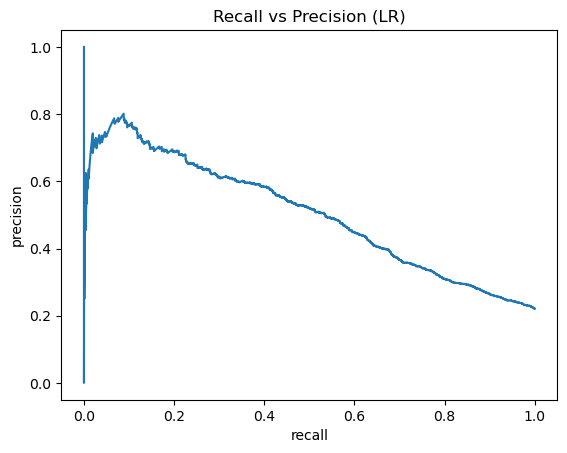

In [84]:
F1_score = np.divide(
    2 * precision[:-1] * recall[:-1],
    precision[:-1] + recall[:-1],
    out=np.zeros_like(precision[:-1]),
    where=(precision[:-1] + recall[:-1]) != 0
)

plt.plot(recall, precision)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Recall vs Precision (LR)")
plt.show()

In [85]:
print(F1_score.max())
print(threshold[np.argmax(F1_score)])

0.5212247738343772
0.5225628148252216


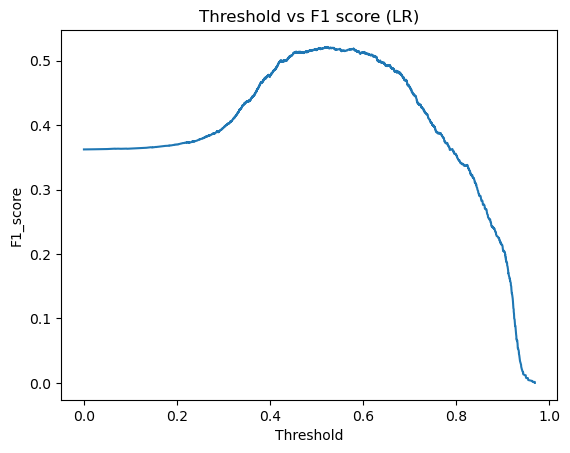

In [86]:
plt.plot(threshold, F1_score)
plt.xlabel("Threshold")
plt.ylabel("F1_score")
plt.title("Threshold vs F1 score (LR)")
plt.show()

In [87]:
best_idx = np.argmax(F1_score)
best_threshold = threshold[best_idx]
best_threshold

np.float64(0.5225628148252216)

In [88]:
y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

print(classification_report(y_val, y_pred_lr))
print(confusion_matrix(y_val, y_pred_lr))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.48      0.56      0.52      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.78      0.77      0.78      6000

[[3875  798]
 [ 578  749]]


### 12.2 RF best estimator

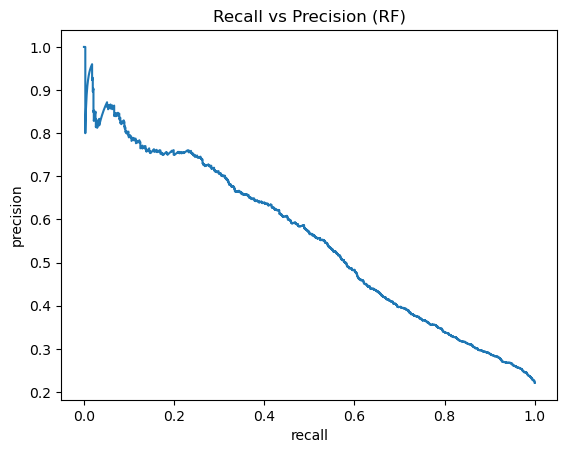

In [89]:
y_prob_rf = best_rf.predict_proba(X_val)[:,1]

precision_rf, recall_rf, threshold_rf = precision_recall_curve(y_val, y_prob_rf)

plt.plot(recall_rf, precision_rf)
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Recall vs Precision (RF)")
plt.show()

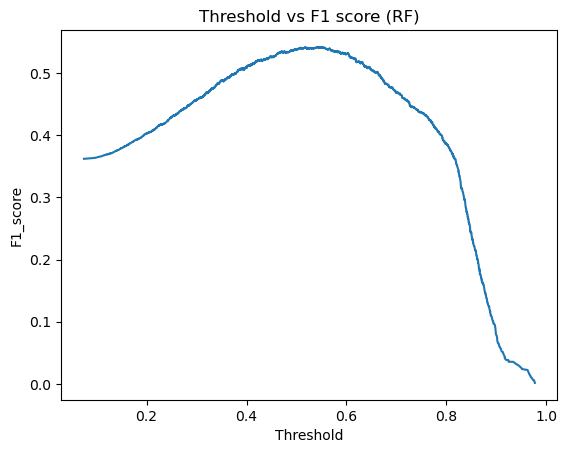

In [90]:
F1_score_rf = (2 * precision_rf[:-1] * recall_rf[:-1])/(precision_rf[:-1] + recall_rf[:-1])

plt.plot(threshold_rf, F1_score_rf)
plt.xlabel("Threshold")
plt.ylabel("F1_score")
plt.title("Threshold vs F1 score (RF)")
plt.show()

In [91]:
best_idx = np.argmax(F1_score_rf)
best_threshold_rf = threshold_rf[best_idx]

y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

In [92]:
print(classification_report(y_val, y_pred_rf))
print(confusion_matrix(y_val, y_pred_rf))
print(f1_score(y_val, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4673
           1       0.55      0.54      0.54      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.71      0.71      6000
weighted avg       0.80      0.80      0.80      6000

[[4078  595]
 [ 612  715]]
0.5422828972317026


### 13. Testing

### 13.1 Testing on Logistic regression

In [93]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

X_train_full = X_train_full.reset_index(drop=True)
y_train_full = y_train_full.reset_index(drop=True)

In [94]:
best_lr.fit(X_train_full, y_train_full)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01


In [95]:
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

y_pred_lr = (y_prob_lr >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(f1_score(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.83      0.85      4673
           1       0.50      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.78      6000

[[3897  776]
 [ 553  774]]
0.5380604796663191


### 13.2 Testing on Randon forest

In [96]:
best_rf.fit(X_train_full, y_train_full)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

y_pred_rf = (y_prob_rf >= best_threshold_rf).astype(int)

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(f1_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4673
           1       0.55      0.56      0.56      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.72      0.72      6000
weighted avg       0.80      0.80      0.80      6000

[[4071  602]
 [ 582  745]]
0.5572176514584891


### 14. conclusions

This project developed a complete machine learning pipeline for credit default prediction, covering exploratory data analysis, feature engineering, model development, hyperparameter optimization, and unbiased evaluation on an unseen test set. Several important insights emerged throughout the experiments.

**Feature engineering** proved that not all engineered variables improve predictive performance. Business-oriented features such as Utilization Ratio and Delinquent Month Count were successfully incorporated into the models. However, introducing aggregated billing and payment averages substantially reduced performance, demonstrating that the detailed monthly financial history contains valuable temporal information that cannot be adequately summarized by simple averages.

**Feature selection** simplified the dataset without materially affecting performance. Selecting only the most informative predictors produced nearly identical cross-validation scores compared to the complete feature set. Although the reduced dataset did not significantly improve predictive performance, it showed that most of the predictive signal is concentrated in a relatively small subset of variables, improving interpretability while maintaining comparable results.

**Logistic Regression** demonstrated remarkable stability. Its cross-validation and test-set F1-scores were nearly identical, indicating excellent generalization and suggesting that the validation procedure provided a reliable estimate of real-world performance.

**Random Forest** achieved the strongest final predictive performance. Although it obtained lower average cross-validation scores than Logistic Regression, hyperparameter tuning and decision-threshold optimization allowed it to achieve the highest F1-score on the unseen test set (0.541). This highlights the importance of evaluating candidate models on truly unseen data, as model rankings observed during cross-validation may not always persist after the complete optimization pipeline.

---

_From a business perspective, an F1-score of 0.541 represents a reasonable balance between identifying customers at risk of default and limiting false alarms. While the model is not intended to replace credit analysts, it could serve as a decision-support tool for prioritizing high-risk customers for further review. In a production environment, additional work such as probability calibration, cost-sensitive learning, external validation, and periodic retraining would be necessary before deployment_.